# Построение линии регрессии  - Предсказание расхода топлива (линейная регрессия)

**Датасет:** [Auto MPG](https://www.kaggle.com/datasets/uciml/autompg-dataset)  - характеристики автомобилей 1970-80-х годов (398 записей, 8 признаков)

**Задача:** предсказать расход топлива (mpg) по техническим характеристикам автомобиля

## 1. Краткая теория

**Линейная регрессия** моделирует зависимость $\hat{y} = w_0 + w_1 x_1 + \ldots + w_n x_n$, минимизируя среднеквадратичную ошибку $MSE = \frac{1}{m}\sum(y_i - \hat{y}_i)^2$.

Аналитическое решение (нормальное уравнение): $\mathbf{w} = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}$. При мультиколлинеарности или переобучении применяется **Ridge-регуляризация** (L2-штраф): $L = MSE + \alpha \sum w_j^2$, где $\alpha$ контролирует силу штрафа. Подробная теория  - в [README.md](README.md).

## 2. Загрузка данных

In [1]:
!pip install -q kagglehub

In [2]:
import kagglehub
import os

path = kagglehub.dataset_download("uciml/autompg-dataset")
csv_path = os.path.join(path, "auto-mpg.csv")
print("Файл:", csv_path)

Файл: C:\Users\danii\.cache\kagglehub\datasets\uciml\autompg-dataset\versions\3\auto-mpg.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

df = pd.read_csv(csv_path)
print(f"Размер: {df.shape}")
df.head()

Размер: (398, 9)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


## 3. Первичный анализ

In [5]:
df.describe()

,mpg,cylinders,displacement,weight,acceleration,model year,origin
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,5140.000000,24.800000,82.000000,3.000000


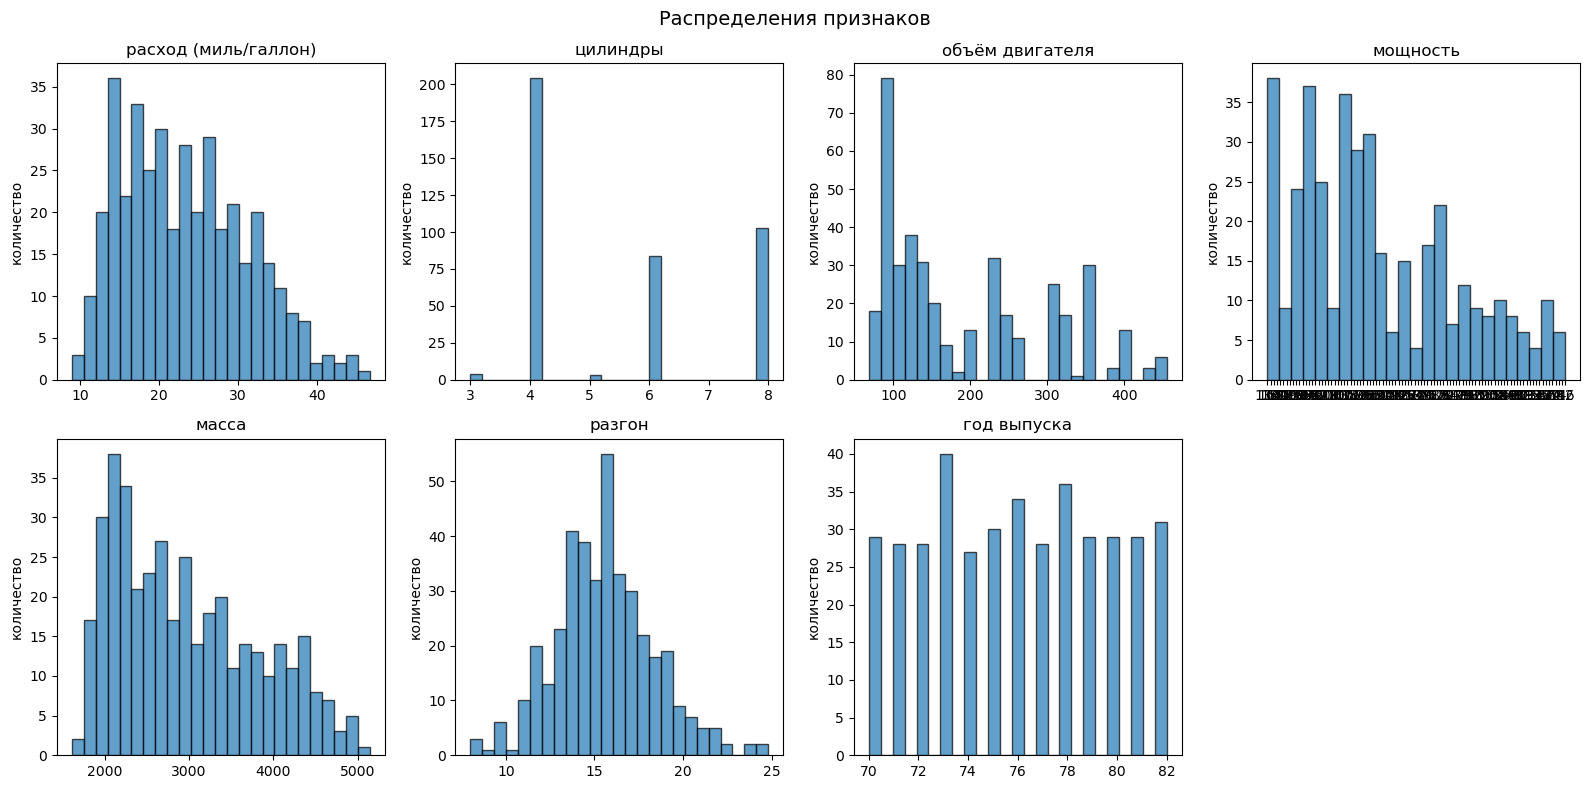

In [6]:
# словарь для перевода названий признаков
feature_names_ru = {
    'mpg': 'расход (миль/галлон)', 'cylinders': 'цилиндры',
    'displacement': 'объём двигателя', 'horsepower': 'мощность',
    'weight': 'масса', 'acceleration': 'разгон',
    'model year': 'год выпуска', 'origin': 'происхождение'
}

# распределения числовых признаков
num_cols = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model year']
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, col in enumerate(num_cols):
    ax = axes[i // 4][i % 4]
    ax.hist(df[col].dropna(), bins=25, edgecolor='black', alpha=0.7)
    ax.set_title(feature_names_ru.get(col, col))
    ax.set_ylabel('количество')
axes[1][3].axis('off')
plt.suptitle('Распределения признаков', fontsize=14)
plt.tight_layout()
plt.show()

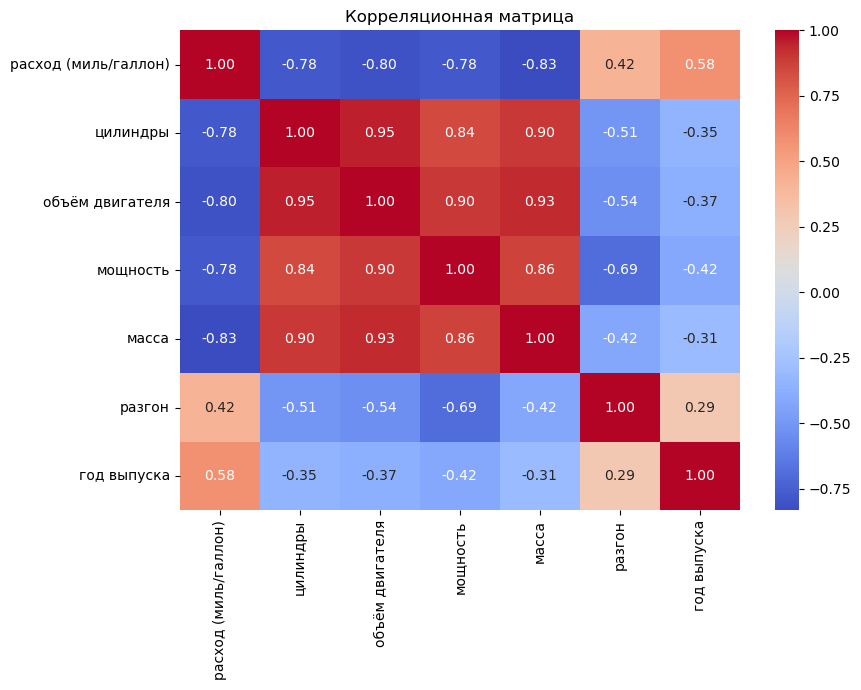

In [7]:
# корреляционная матрица
# horsepower может содержать '?'  - приведём к числовому типу
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')

corr = df[num_cols].corr()
corr.index = [feature_names_ru[c] for c in corr.index]
corr.columns = [feature_names_ru[c] for c in corr.columns]

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Корреляционная матрица')
plt.tight_layout()
plt.show()

In [8]:
# пропуски
print("Пропуски по признакам:")
print(df.isnull().sum())
print(f"\nВсего строк с пропусками: {df.isnull().any(axis=1).sum()}")

Пропуски по признакам:
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64

Всего строк с пропусками: 6


Масса, объём двигателя и мощность сильно коррелируют между собой (r > 0.8) и отрицательно с mpg. Год выпуска положительно влияет на mpg  - более новые автомобили экономичнее. Пропуски есть только в horsepower (6 строк из 398).

## 4. Предобработка

In [9]:
# удаляем строки с пропусками в horsepower (6 из 398  - незначительная потеря)
df = df.dropna(subset=['horsepower'])

# удаляем car name  - текстовый идентификатор, не признак
df = df.drop(columns=['car name'])

# origin  - категориальный признак (1=США, 2=Европа, 3=Япония), кодируем one-hot
df = pd.get_dummies(df, columns=['origin'], prefix='происхождение', dtype=int)

print(f"Размер после очистки: {df.shape}")
df.head()

Размер после очистки: (392, 10)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,происхождение_1,происхождение_2,происхождение_3
0,18.0,8,307.0,130.0,3504,12.0,70,1,0,0
1,15.0,8,350.0,165.0,3693,11.5,70,1,0,0
2,18.0,8,318.0,150.0,3436,11.0,70,1,0,0
3,16.0,8,304.0,150.0,3433,12.0,70,1,0,0
4,17.0,8,302.0,140.0,3449,10.5,70,1,0,0


### Разбиение и масштабирование

In [10]:
X = df.drop(columns=['mpg'])
y = df['mpg']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print(f"Train: {X_train_sc.shape[0]}, Test: {X_test_sc.shape[0]}")

Train: 313, Test: 79


## 5. Обучение модели

### Baseline  - обычная линейная регрессия (OLS)

In [11]:
lr = LinearRegression()
lr.fit(X_train_sc, y_train)

y_pred_lr = lr.predict(X_test_sc)

print(f"LinearRegression (baseline):")
print(f"  R2:   {r2_score(y_test, y_pred_lr):.4f}")
print(f"  MAE:  {mean_absolute_error(y_test, y_pred_lr):.4f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lr)):.4f}")

LinearRegression (baseline):
  R2:   0.7923
  MAE:  2.4620
  RMSE: 3.2561


### Подбор гиперпараметра alpha для Ridge

Лучший alpha: 2.6827
Лучший R2 (CV): 0.8110


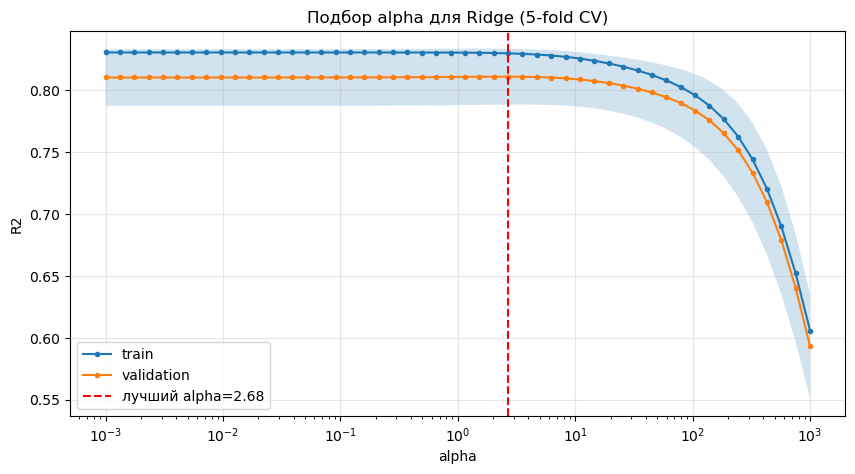

In [12]:
alphas = np.logspace(-3, 3, 50)
ridge_cv = GridSearchCV(
    Ridge(), param_grid={'alpha': alphas},
    scoring='r2', cv=5, return_train_score=True
)
ridge_cv.fit(X_train_sc, y_train)

print(f"Лучший alpha: {ridge_cv.best_params_['alpha']:.4f}")
print(f"Лучший R2 (CV): {ridge_cv.best_score_:.4f}")

# график R2 от alpha
results = ridge_cv.cv_results_
plt.figure(figsize=(10, 5))
plt.semilogx(alphas, results['mean_train_score'], label='train', marker='o', markersize=3)
plt.semilogx(alphas, results['mean_test_score'], label='validation', marker='o', markersize=3)
plt.fill_between(alphas,
                 results['mean_test_score'] - results['std_test_score'],
                 results['mean_test_score'] + results['std_test_score'],
                 alpha=0.2)
plt.axvline(ridge_cv.best_params_['alpha'], color='red', linestyle='--', label=f"лучший alpha={ridge_cv.best_params_['alpha']:.2f}")
plt.xlabel('alpha')
plt.ylabel('R2')
plt.title('Подбор alpha для Ridge (5-fold CV)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Финальная модель Ridge с лучшим alpha

In [13]:
model = ridge_cv.best_estimator_
y_pred = model.predict(X_test_sc)

print(f"Ridge (alpha={ridge_cv.best_params_['alpha']:.4f}):")
print(f"  R2:   {r2_score(y_test, y_pred):.4f}")
print(f"  MAE:  {mean_absolute_error(y_test, y_pred):.4f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

Ridge (alpha=2.6827):
  R2:   0.7893
  MAE:  2.4670
  RMSE: 3.2790


Baseline LinearRegression (R2=0.7923) и Ridge с alpha=2.68 (R2=0.7893) дают практически одинаковые результаты. Регуляризация не даёт выигрыша  - при 9 признаках и 392 наблюдениях переобучение не проблема. R2 на кросс-валидации (0.8110) близок к тестовому  - модель стабильна.

## 6. Оценка качества

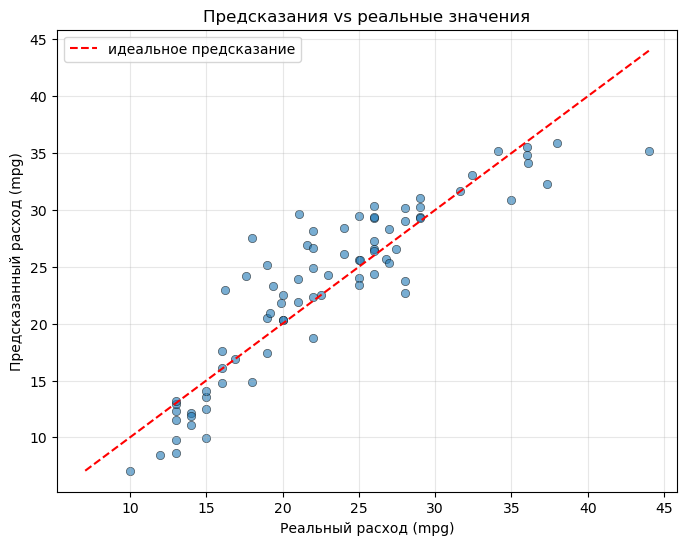

In [14]:
# предсказания vs реальные значения
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, edgecolors='black', linewidths=0.5)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='идеальное предсказание')
plt.xlabel('Реальный расход (mpg)')
plt.ylabel('Предсказанный расход (mpg)')
plt.title('Предсказания vs реальные значения')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Точки хорошо ложатся на диагональ. Наибольшие отклонения  - у автомобилей с высоким mpg (> 35), где модель занижает предсказания.

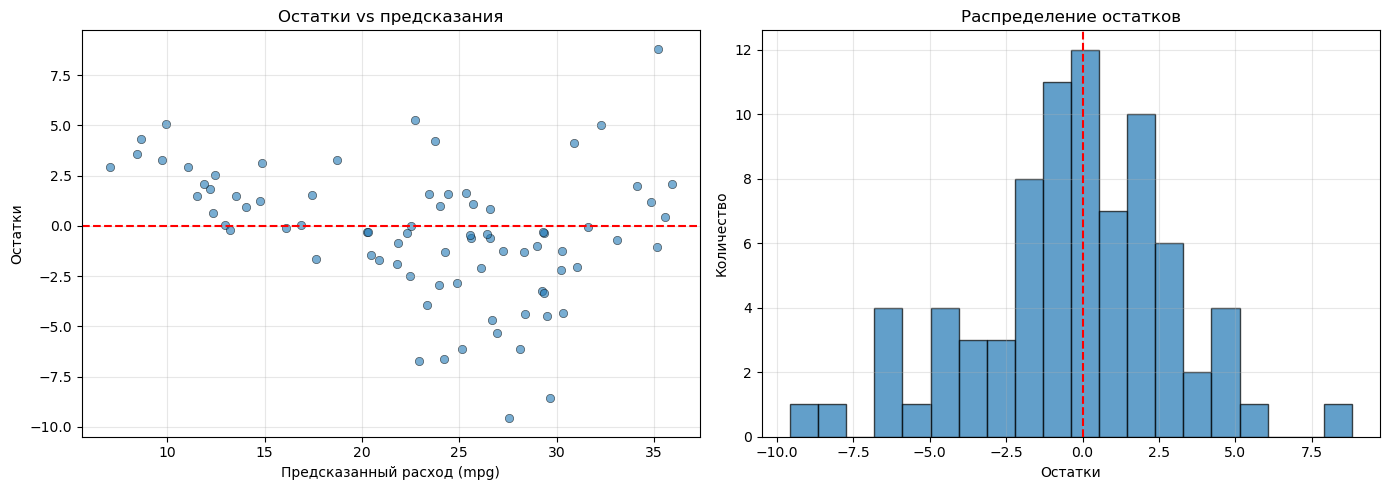

Среднее остатков: -0.3575
Стд. отклонение остатков: 3.2803


In [15]:
# распределение остатков
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# остатки vs предсказания
axes[0].scatter(y_pred, residuals, alpha=0.6, edgecolors='black', linewidths=0.5)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Предсказанный расход (mpg)')
axes[0].set_ylabel('Остатки')
axes[0].set_title('Остатки vs предсказания')
axes[0].grid(True, alpha=0.3)

# гистограмма остатков
axes[1].hist(residuals, bins=20, edgecolor='black', alpha=0.7)
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Остатки')
axes[1].set_ylabel('Количество')
axes[1].set_title('Распределение остатков')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Среднее остатков: {residuals.mean():.4f}")
print(f"Стд. отклонение остатков: {residuals.std():.4f}")

Остатки распределены приблизительно нормально (среднее -0.36, стд. 3.28). На графике остатков vs предсказаний нет явного паттерна  - линейная модель адекватна данным.

### Важность признаков (коэффициенты модели)

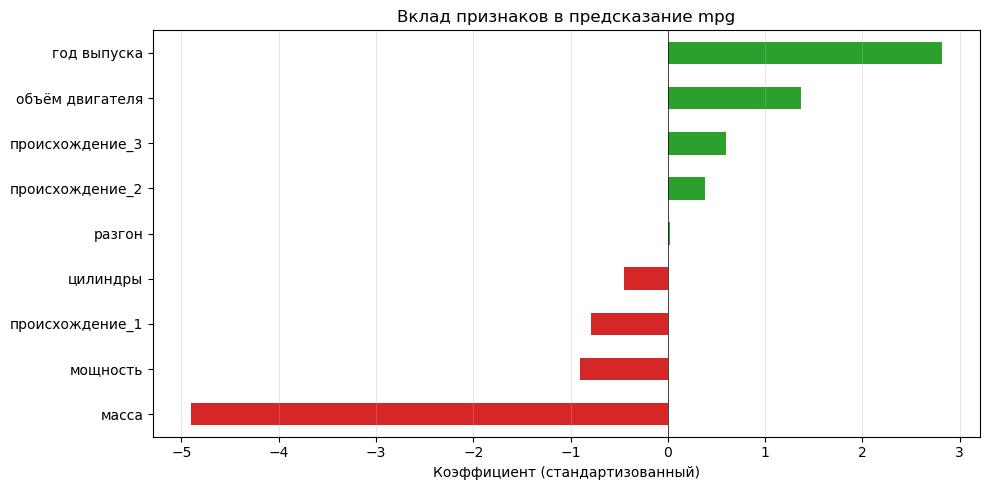

In [16]:
# коэффициенты Ridge-модели (на стандартизованных признаках  - сравнимы между собой)
feature_labels = [feature_names_ru.get(c, c) for c in X.columns]
coefs = pd.Series(model.coef_, index=feature_labels).sort_values()

plt.figure(figsize=(10, 5))
colors = ['#d62728' if c < 0 else '#2ca02c' for c in coefs]
coefs.plot(kind='barh', color=colors)
plt.xlabel('Коэффициент (стандартизованный)')
plt.title('Вклад признаков в предсказание mpg')
plt.axvline(0, color='black', linewidth=0.5)
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

Наибольший отрицательный вклад  - масса автомобиля: чем тяжелее машина, тем ниже mpg. Год выпуска  - главный положительный фактор: технологический прогресс улучшает экономичность.